# Setup

In [1]:
lapply(c('viridis', 'ggthemes', 'skimr'),
       function(pkg_name) { if(! pkg_name %in% installed.packages()) { install.packages(pkg_name)} } )

library(viridis)    # A nice color scheme for plots.
library(ggthemes)   # Common themes to change the look and feel of plots.
library(scales)     # Graphical scales map data to aesthetics in plots.
library(skimr)      # Better summaries of data.
library(lubridate)  # Date library from the tidyverse.
library(tidyverse)  # Data wrangling packages.
library(bigrquery)  # Data extraction from Google BigQuery
library(data.table )

# Load required libraries
library(dplyr)
library(tidyr)
library(purrr)
library(broom)
install.packages("pheatmap")
library(pheatmap)
library(grid)

## Plot setup.
theme_set(theme_bw(base_size = 14)) # Default theme for plots.

#' Returns a data frame with a y position and a label, for use annotating ggplot boxplots.
#'
#' @param d A data frame.
#' @return A data frame with column y as max and column label as length.
get_boxplot_fun_data <- function(df) {
  return(data.frame(y = max(df), label = stringr::str_c('N = ', length(df))))
}

# Get the bucket name
my_bucket <- Sys.getenv('WORKSPACE_BUCKET')

[[1]]
NULL

[[2]]
NULL

[[3]]
NULL

Loading required package: viridisLite


Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr   1.1.4     ✔ readr   2.1.5
✔ forcats 1.0.0     ✔ stringr 1.5.1
✔ ggplot2 3.5.2     ✔ tibble  3.2.1
✔ purrr   1.0.4     ✔ tidyr   1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor() masks scales::col_factor()
✖ purrr::discard()    masks scales::discard()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is

In [2]:
name_of_file_in_bucket <- 'All_SDoH_data_domain_filtered_60.csv'

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)

# Load the file into a dataframe
sdoh_data  <- read_csv(name_of_file_in_bucket)
sdoh_data <- sdoh_data |> select(-c("Education"))

character(0)

Rows: 54313 Columns: 54
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (6): SexGender, where_born, military, healthcare, disabled, sexual_ori...
dbl  (37): person_id, race_unknown, age_today, LGBTQIA, ehr_length, relative...
lgl   (8): AIAN, Asian, Black, Mid, Multiple, PI, White, His
date  (3): date_of_birth, min_date, max_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Load and merge data

In [3]:
# replace 'test.csv' with the name of the file in your google bucket (don't delete the quotation marks)
name_of_file_in_bucket <- 'Case_Control_df.csv'

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)

# Load the file into a dataframe
Case_Control_df  <- read_csv(name_of_file_in_bucket)

character(0)

Rows: 265954 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (10): person_id, Asthma, Afib, BreastC, CKD, CHD, HyperC, ProstateC, t2d...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
merged_data<-merge(sdoh_data, Case_Control_df, on="person_id", how="left")

domains<-c('NBE', 'ES', 'Edu', "SCC", "HCAU")

In [5]:
system(paste0("gsutil cp ", my_bucket, "/data/disease_sdoh_association_effect_sizes.csv ."), intern = TRUE)

# Load the file into a dataframe
log_reg_res  <- read_csv("disease_sdoh_association_effect_sizes.csv")

character(0)

Rows: 297 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): term, Disease, SDoH_Variable, Domain
dbl (8): estimate, std.error, statistic, p.value, SD_predictor, OR, OR_Lower...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Summary Table

In [38]:
summary_table_ind <- log_reg_res |>
  group_by(term) |>
  summarise(
    n = n(),
    mean_OR = mean(ifelse(OR < 1, 1/OR, OR), na.rm = TRUE),
    median_OR = median(ifelse(OR < 1, 1/OR, OR), na.rm = TRUE),
    sd_OR = sd(ifelse(OR < 1, 1/OR, OR), na.rm = TRUE),
    min_OR = min(ifelse(OR < 1, 1/OR, OR), na.rm = TRUE),
    max_OR = max(ifelse(OR < 1, 1/OR, OR), na.rm = TRUE),
    .groups = "drop"
  ) |>
  arrange(desc(mean_OR))

summary_table_ind 

mean(summary_table_ind$mean_OR)

term,n,mean_OR,median_OR,sd_OR,min_OR,max_OR
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Percent.Poverty.Threshold,9,1.367827,1.231631,0.30885906,1.045904,1.888098
ES,9,1.357978,1.268517,0.24095112,1.095505,1.797823
Education,9,1.281267,1.290941,0.19213979,1.051028,1.620170
HCAU,9,1.223782,1.206900,0.11420054,1.077589,1.419251
Healthcare.Utilization,9,1.202694,1.178198,0.09574454,1.052937,1.409430
Food.Insecurity,9,1.198723,1.167052,0.12869245,1.047902,1.437363
Own.Home,9,1.195400,1.142660,0.14091985,1.040028,1.478653
SCC,9,1.187779,1.208075,0.07958684,1.069524,1.319388
Can.t.afford.care,9,1.185064,1.176902,0.09210837,1.052564,1.334197


[1] 1.161977

## Set up lists

In [7]:
diseases<-c("Asthma", "Afib", "BreastC", "CKD", "CHD", "HyperC", "ProstateC", "t2d", "t1d")
ind_domains<-c("SCC", "NBE", "ES", "HCAU", "Edu")

In [8]:
disease_name_mapping <- c(
  "Asthma" = "Asthma",
  "Afib" = "Atrial\nFibrillation",
  "BreastC" = "Breast Cancer",
  "CKD" = "Chronic Kidney\nDisease",
  "CHD" = "Coronary Heart\nDisease", 
  "HyperC" = "Hypercholest-\nerolemia",
  "ProstateC" = "Prostate Cancer",
  "t2d" = "Type 2 Diabetes",
  "t1d" = "Type 1 Diabetes"
)

ind_domain_name_mapping <- c(
  "SCC" = "SCC Deprivation",
  "NBE" = "NBE Deprivation",
  "ES" = "Lower ES",
  "HCAU" = "Lower HCAU",
  "Education" = "Lower Education"
)

# Plot Heatmap

## Individual-level

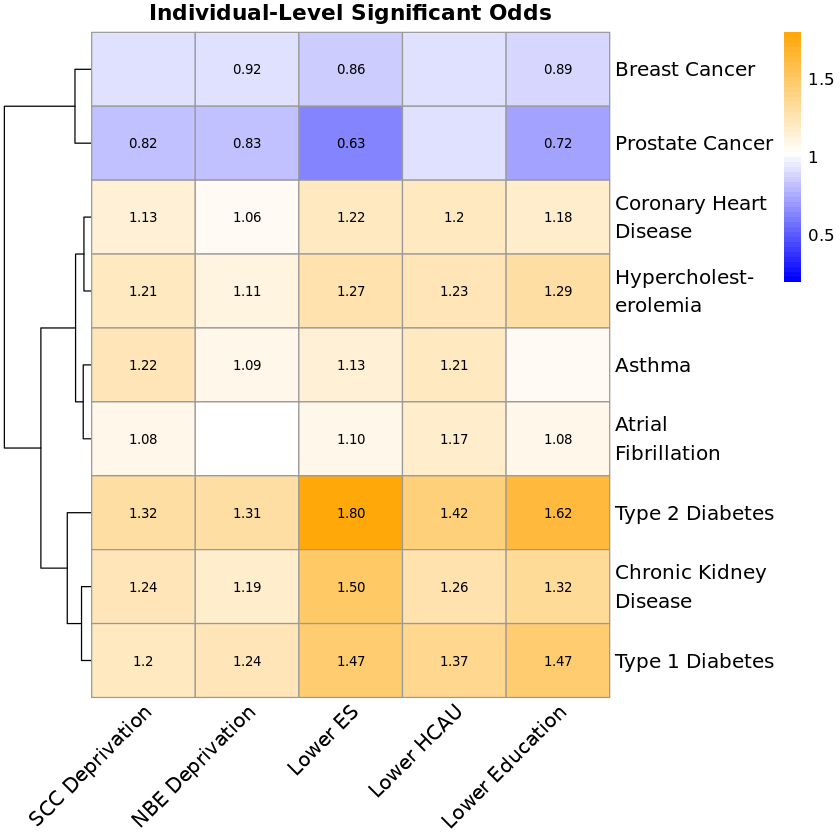

In [9]:
ind_domains<-c("SCC", "NBE", "ES", "HCAU", "Education")

x_axis_order <- c("SCC", "NBE", "ES", "HCAU", "Education")

# Filter to SDoH domain coefficients only
all_coefficients_clean <- log_reg_res %>%
  filter(term %in% ind_domains) %>%
  ungroup()


# Wide format for coefficients (heatmap values)
heatmap_data_ind <- all_coefficients_clean %>%
  select(Disease, term, OR) %>%
  pivot_wider(names_from = term, values_from = OR) %>%
  column_to_rownames("Disease") %>%
  select(all_of(x_axis_order))

# Wide format for p-values (mask)
pvalue_data <- all_coefficients_clean %>%
  select(Disease, term, p.value) %>%
  pivot_wider(names_from = term, values_from = p.value) %>%
  column_to_rownames("Disease") %>%
  select(all_of(x_axis_order))

# Apply Bonferroni mask (significance threshold)
alpha <- 0.05 / (length(unique(log_reg_res$Disease)) * 10)
significance_mask_ind <- pvalue_data < alpha

# Format labels for display (only show significant values)
heatmap_labels_ind <- round(heatmap_data_ind, 2)
heatmap_labels_ind[!significance_mask_ind] <- ""

#Rename rows to be full Disease names
rownames(heatmap_data_ind) <- disease_name_mapping[rownames(heatmap_data_ind)]
colnames(heatmap_data_ind) <- ind_domain_name_mapping[colnames(heatmap_data_ind)]


# Create diverging color palette centered on 0
max_val <- max(abs(heatmap_data_ind), na.rm = TRUE)
min_val <- min(abs(heatmap_data_ind), na.rm = TRUE)
breaks <- seq(0.2, 1.8, length.out = 51)
palette <- colorRampPalette(c("blue", "white", "orange"))(length(breaks) )

# Plot the heatmap
ind_map_log<-pheatmap(
  mat = heatmap_data_ind,
  color = palette,
  breaks = breaks,
  cluster_rows = TRUE, #match row order as above
  cluster_cols = FALSE,
  display_numbers = heatmap_labels_ind,
  number_color = "black",
  fontsize_row = 12,
  fontsize_col = 12,
  angle_col = 45,
  main = "Individual-Level Significant Odds",
  width = 3,
  height = 1
)


## Area-level

In [10]:
label_mapping <- c(
  "vacant_housing" = "Vacant Housing",
  "lower_median_income" = "Lower Median Income",
  "no_health_insurance" = "No Health Insurance",
  "no_high_school_education" = "No High School Education",
  "deprivation_index" = "Deprivation Index"
)

area_domains <-c("vacant_housing", "lower_median_income", "no_health_insurance",
                "no_high_school_education", "deprivation_index")

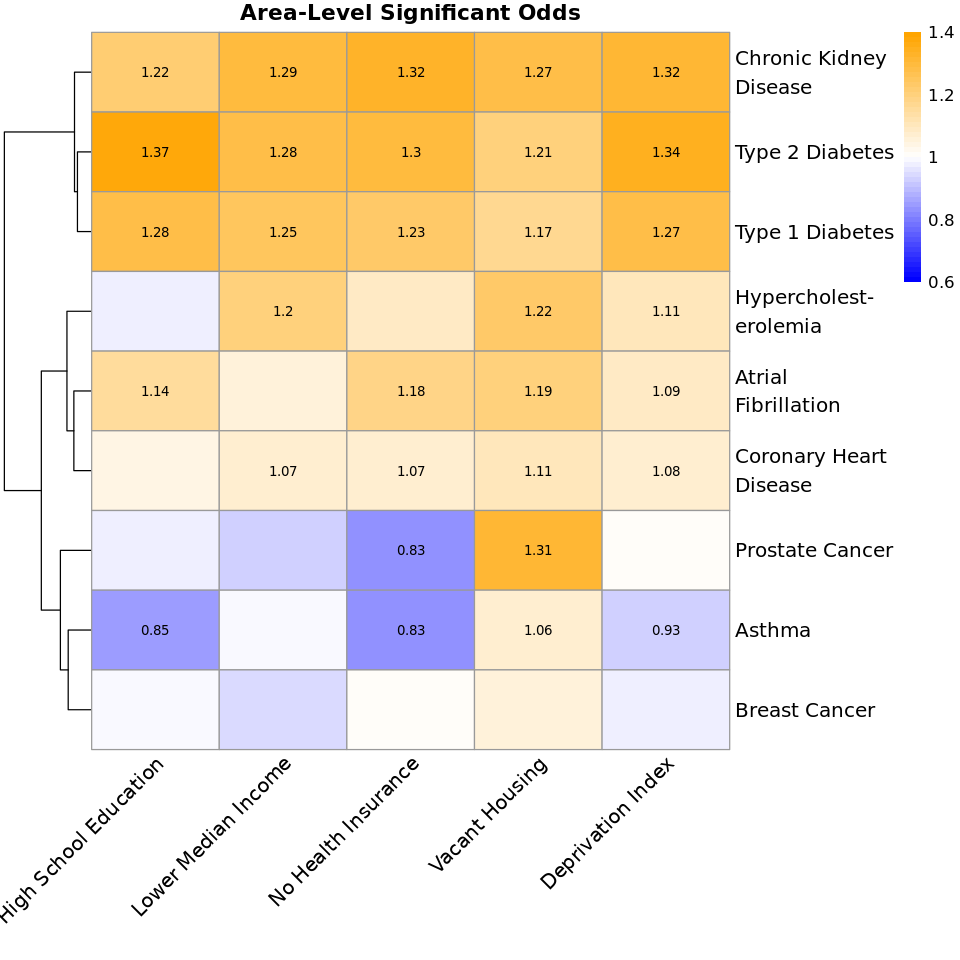

In [11]:
options(repr.plot.width = 8, repr.plot.height = 8)

all_coefficients_clean <- log_reg_res %>%
  filter(term %in% area_domains) %>%
  ungroup()

# Wide format for coefficients (heatmap values)
heatmap_data_area <- all_coefficients_clean %>%
  select(Disease, term, OR) %>%
  pivot_wider(names_from = term, values_from = OR) %>%
  column_to_rownames("Disease")

# Wide format for p-values (mask)
pvalue_data <- all_coefficients_clean %>%
  select(Disease, term, p.value) %>%
  pivot_wider(names_from = term, values_from = p.value) %>%
  column_to_rownames("Disease")

# Apply Bonferroni mask (significance threshold)
alpha <- 0.05 / (length(unique(log_reg_res$Disease)) * 10)
significance_mask_area <- pvalue_data < alpha

# Format labels for display (only show significant values)
heatmap_labels_area <- round(heatmap_data_area, 2)
heatmap_labels_area[!significance_mask_area] <- ""

#Make row and column names more proffessional 
rownames(heatmap_data_area) <- disease_name_mapping[rownames(heatmap_data_area)]
colnames(heatmap_data_area) <- label_mapping[colnames(heatmap_data_area)]

# Create diverging color palette centered on 0
#max_val <- max(abs(heatmap_data_area), na.rm = TRUE)
breaks <- seq(.6, 1.4, length.out = 51)
palette <- colorRampPalette(c("blue", "white", "orange"))(length(breaks) - 1)

# Plot the heatmap
area_map<-pheatmap(
  mat = heatmap_data_area,
  color = palette,
  breaks = breaks,
  cluster_rows = TRUE,
  cluster_cols = FALSE,
  display_numbers = heatmap_labels_area,
  number_color = "black",
  fontsize_row = 12,
  fontsize_col = 12,
  angle_col = 45,
  main = "Area-Level Significant Odds",
  width = 3,
  height = 1
)



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




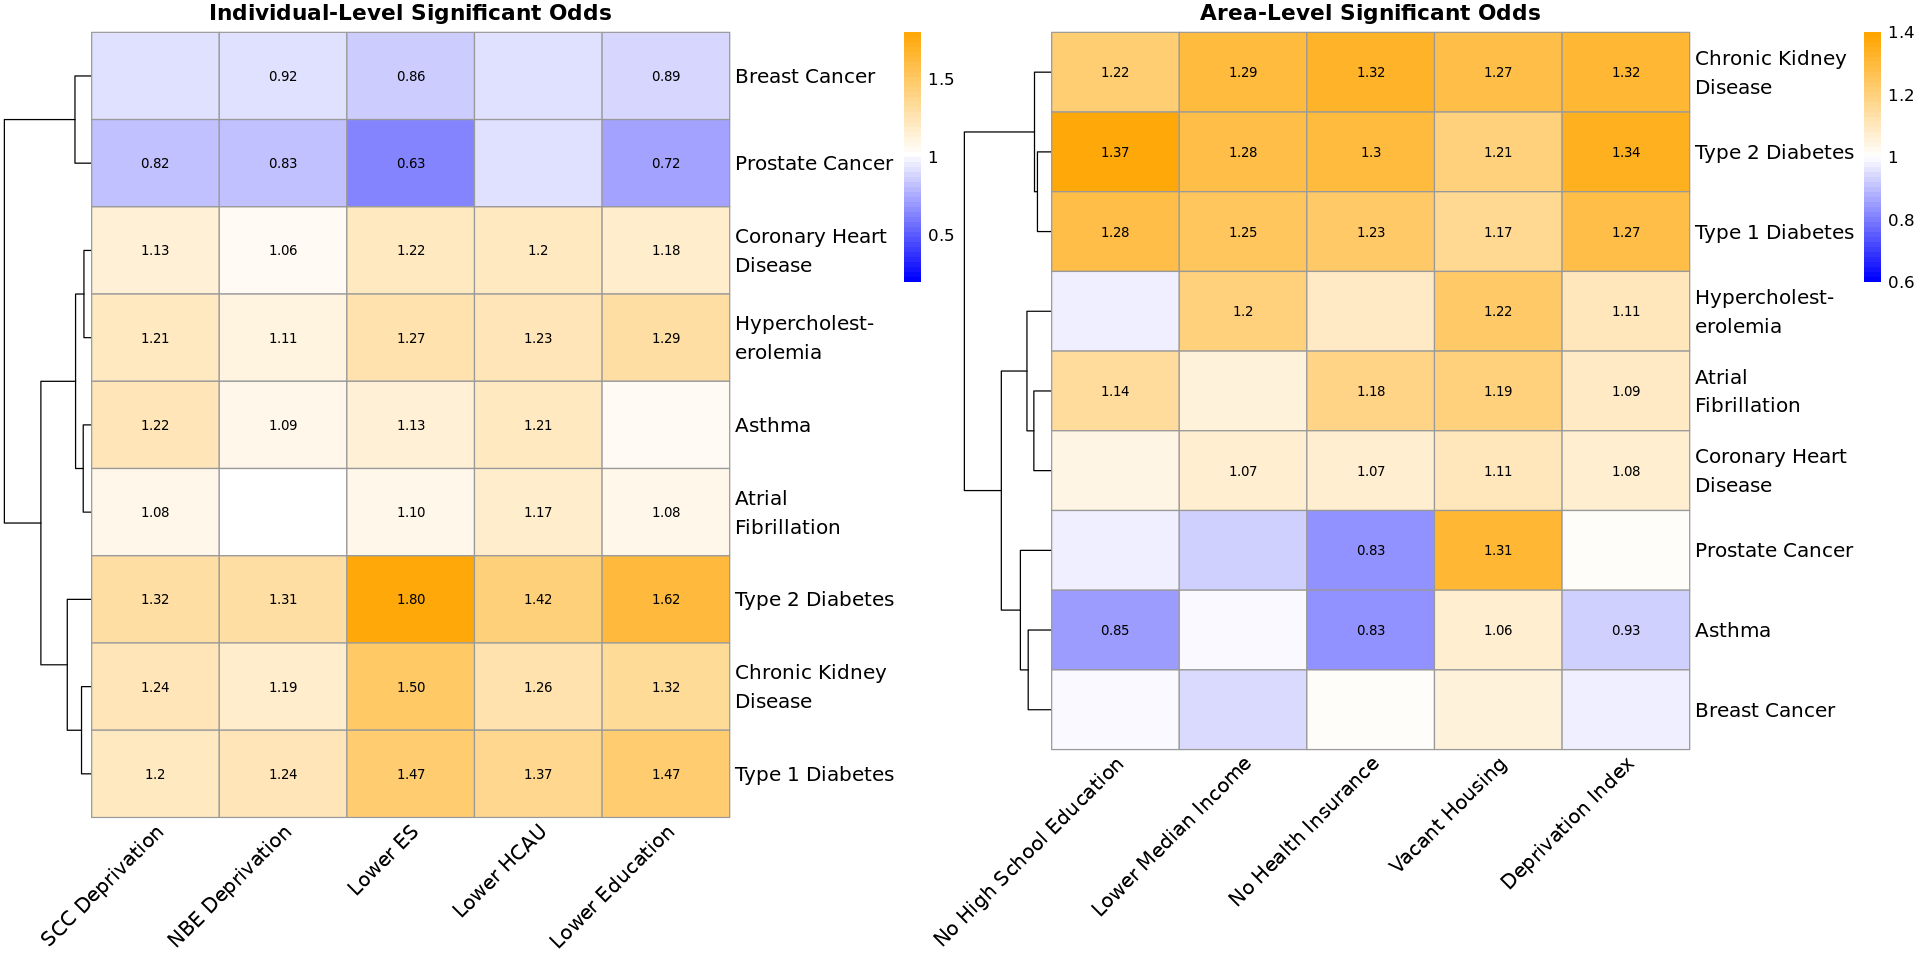

In [12]:
options(repr.plot.width = 16, repr.plot.height = 8)

library(gridExtra)
grid.arrange(ind_map_log$gtable, area_map$gtable, nrow = 1) 


## Finalize Heatmaps for Publication

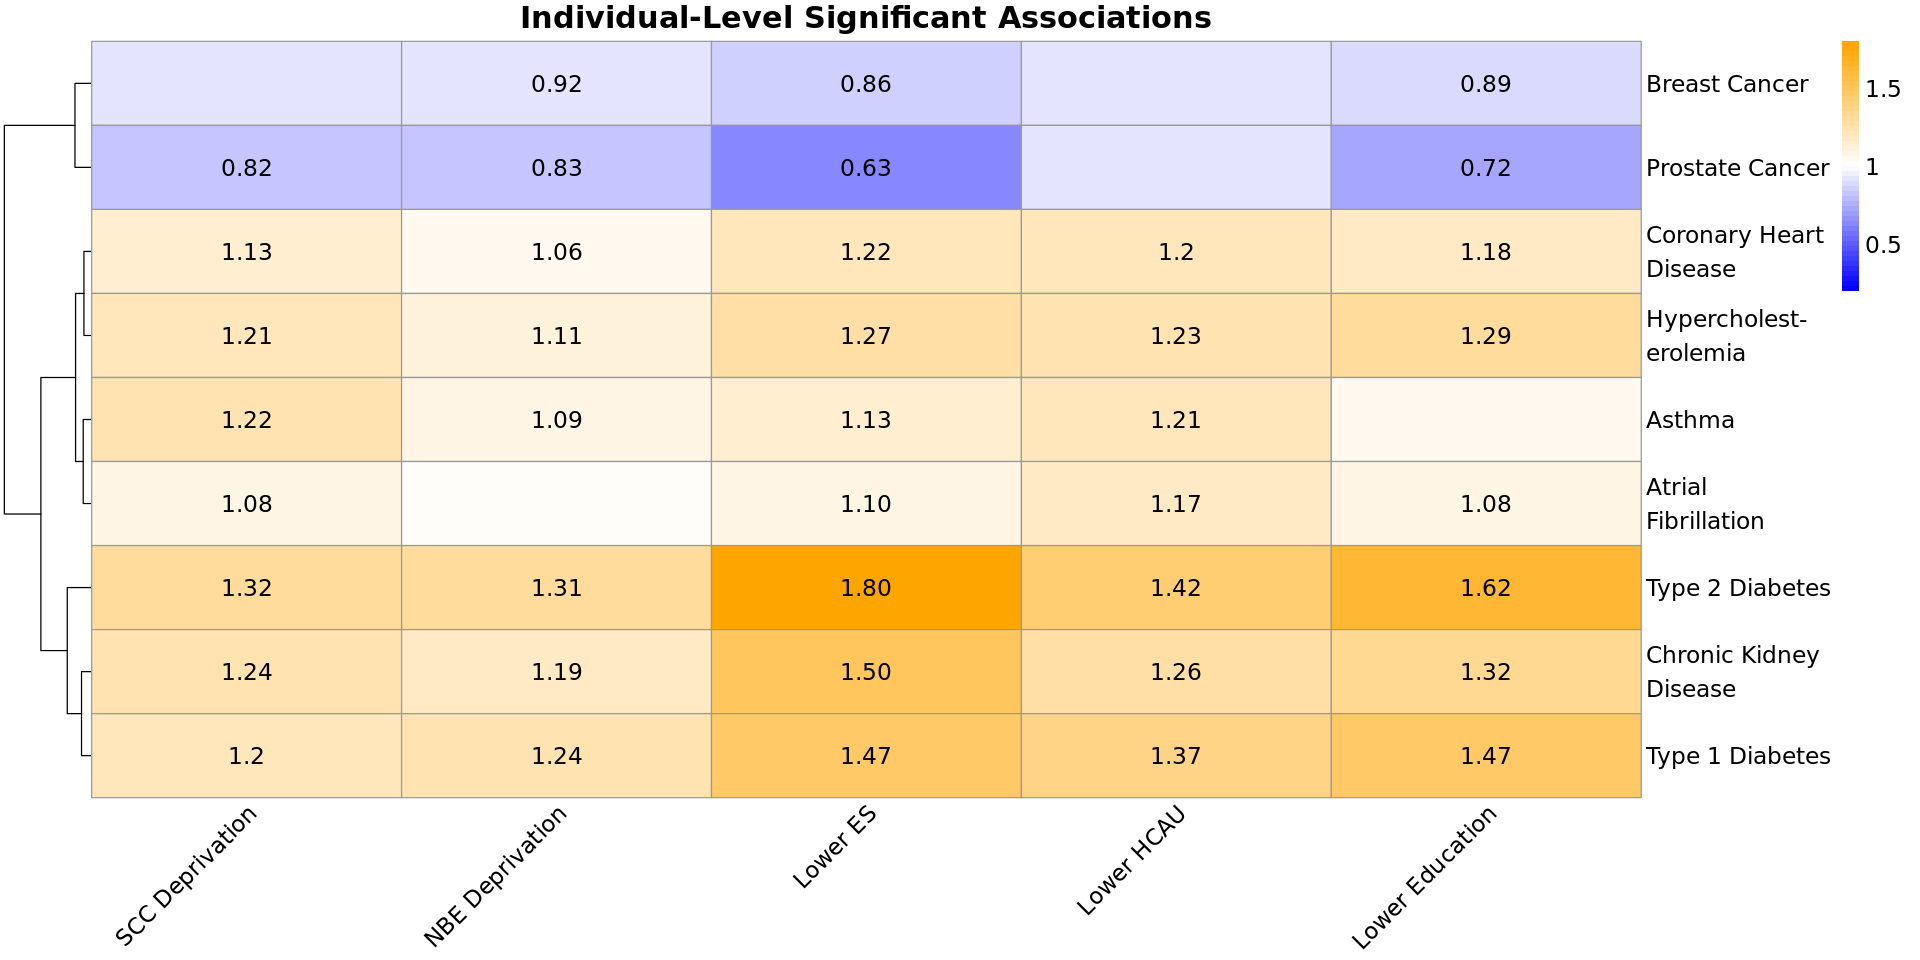

In [13]:
breaks <- seq(.2, 1.8, length.out = 51)
palette <- colorRampPalette(c("blue", "white", "orange"))(length(breaks) - 1)


#Getting the order to make the color masks 
number_colors <- matrix("black", nrow = nrow(heatmap_data_ind), ncol = ncol(heatmap_data_ind))
number_colors[heatmap_data_ind < -1] <- "white"

row_order <- ind_map_log$tree_row$order

heatmap_labels_ordered <- heatmap_labels_ind[row_order, , drop = FALSE]
number_colors_ordered <- number_colors[row_order, , drop = FALSE]


# Regenerate the heatmap with aligned annotations
ind_map_ordered<-pheatmap(
  mat = heatmap_data_ind[row_order, , drop = FALSE],
  color = palette,
  breaks = breaks,
  cluster_rows = TRUE,  # Set to FALSE since we've already clustered
  cluster_cols = FALSE,
  display_numbers = heatmap_labels_ordered,
  fontsize_number = 14, 
  fontsize = 14, 
  number_color = number_colors_ordered,
  fontsize_row = 14,
  fontsize_col = 14,
  angle_col = 45,
  main = "Individual-Level Significant Associations",
  width = 3,
  height = 1
)

ggsave("ind_sig_probit_heatmap_sem.png", plot = ind_map_ordered, width = 8, height = 8, dpi = 300)

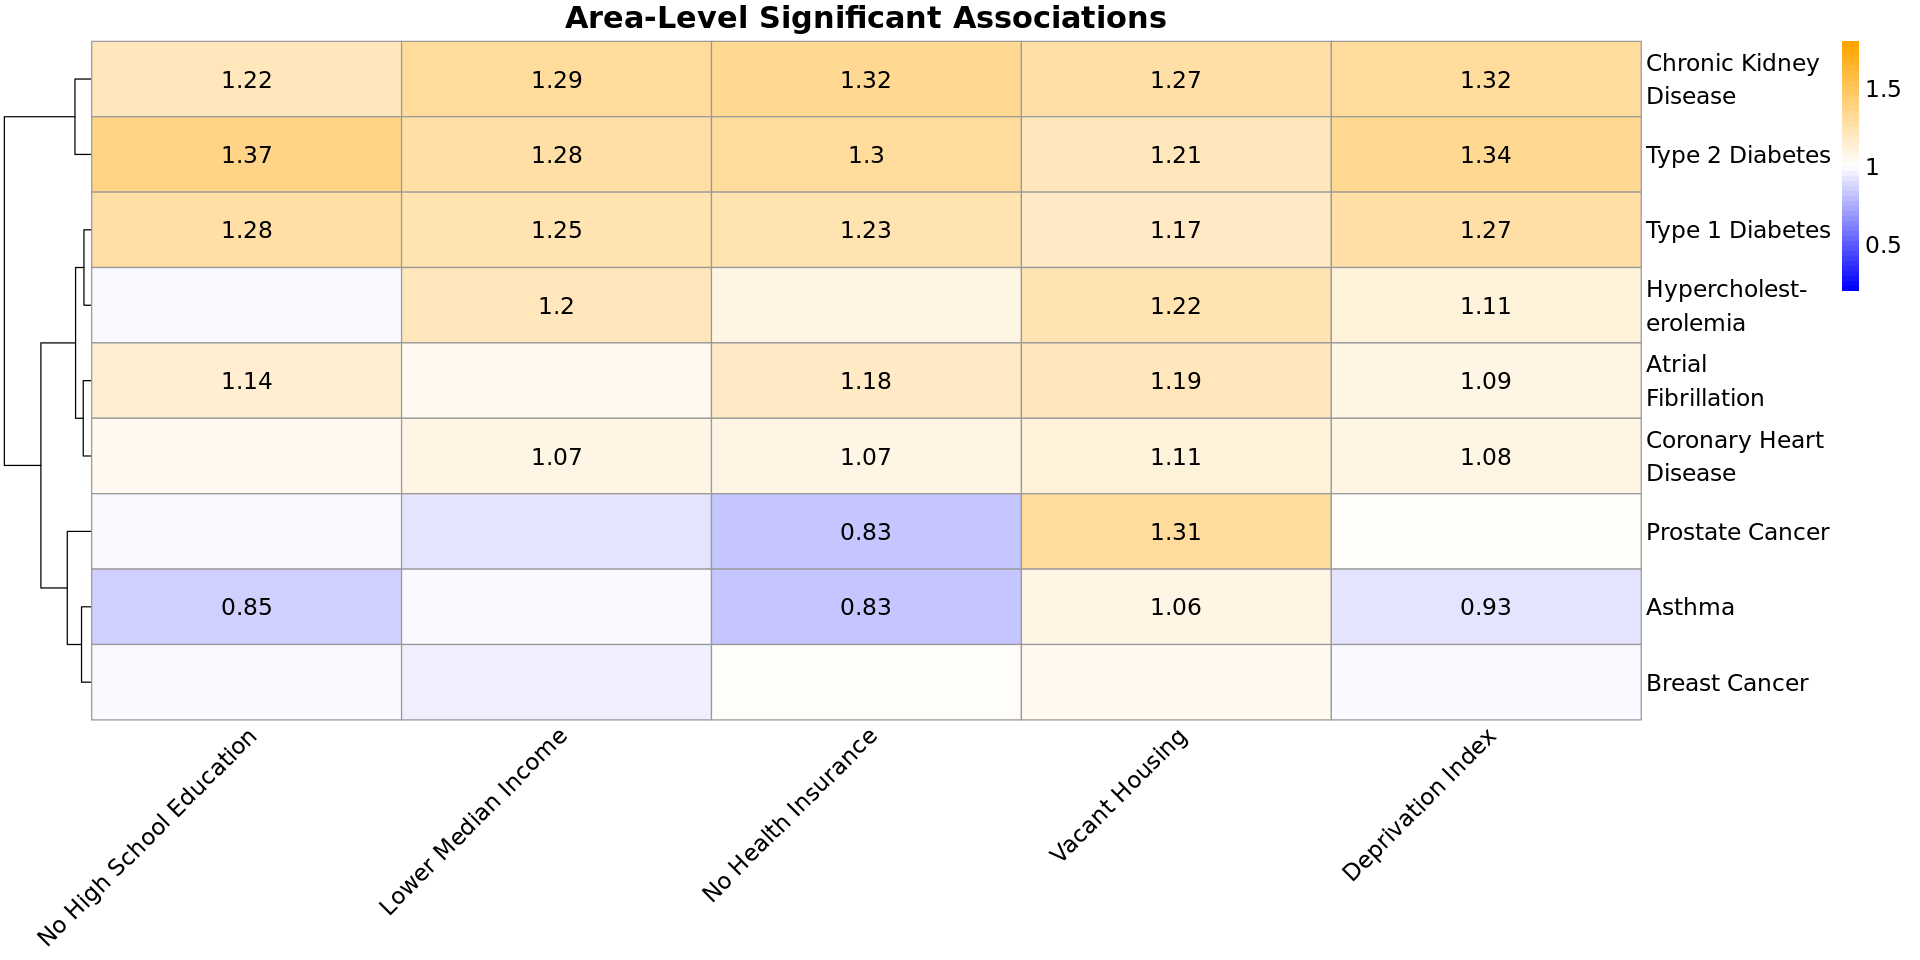

In [14]:
#Getting the order to make the color masks 
number_colors <- matrix("black", nrow = nrow(heatmap_data_area), ncol = ncol(heatmap_data_area))
number_colors[heatmap_data_area < -1] <- "white"

row_order <- area_map$tree_row$order

heatmap_labels_ordered <- heatmap_labels_area[row_order, , drop = FALSE]
number_colors_ordered <- number_colors[row_order, , drop = FALSE]

# Regenerate the heatmap with aligned annotations
area_map_ordered<-pheatmap(
  mat = heatmap_data_area[row_order, , drop = FALSE],
  color = palette,  # Diverging color scale
  breaks = breaks,  # Center scale at 0
  cluster_rows = ind_map_ordered$tree_row,  # Cluster diseases
  cluster_cols = FALSE,  # Do not cluster columns (respect custom order)
  main = "Area-Level Significant Associations",
  fontsize_number = 14, 
  fontsize = 14, 
  fontsize_row = 14,  # Font size for row labels
  fontsize_col = 14,  # Font size for column labels
  display_numbers = heatmap_labels_ordered,  # Show effect sizes in cells
  number_color = number_colors_ordered,  # Color of the numbers
  number_format = "%.2f",  # Format for numbers in cells
  height = 1,  # Increase vertical size of the heatmap
  width=3,
   angle_col = 45  
)


ggsave("area_sig_probit_heatmap_sem.png", plot = area_map_ordered, width = 8, height = 8, dpi = 300)


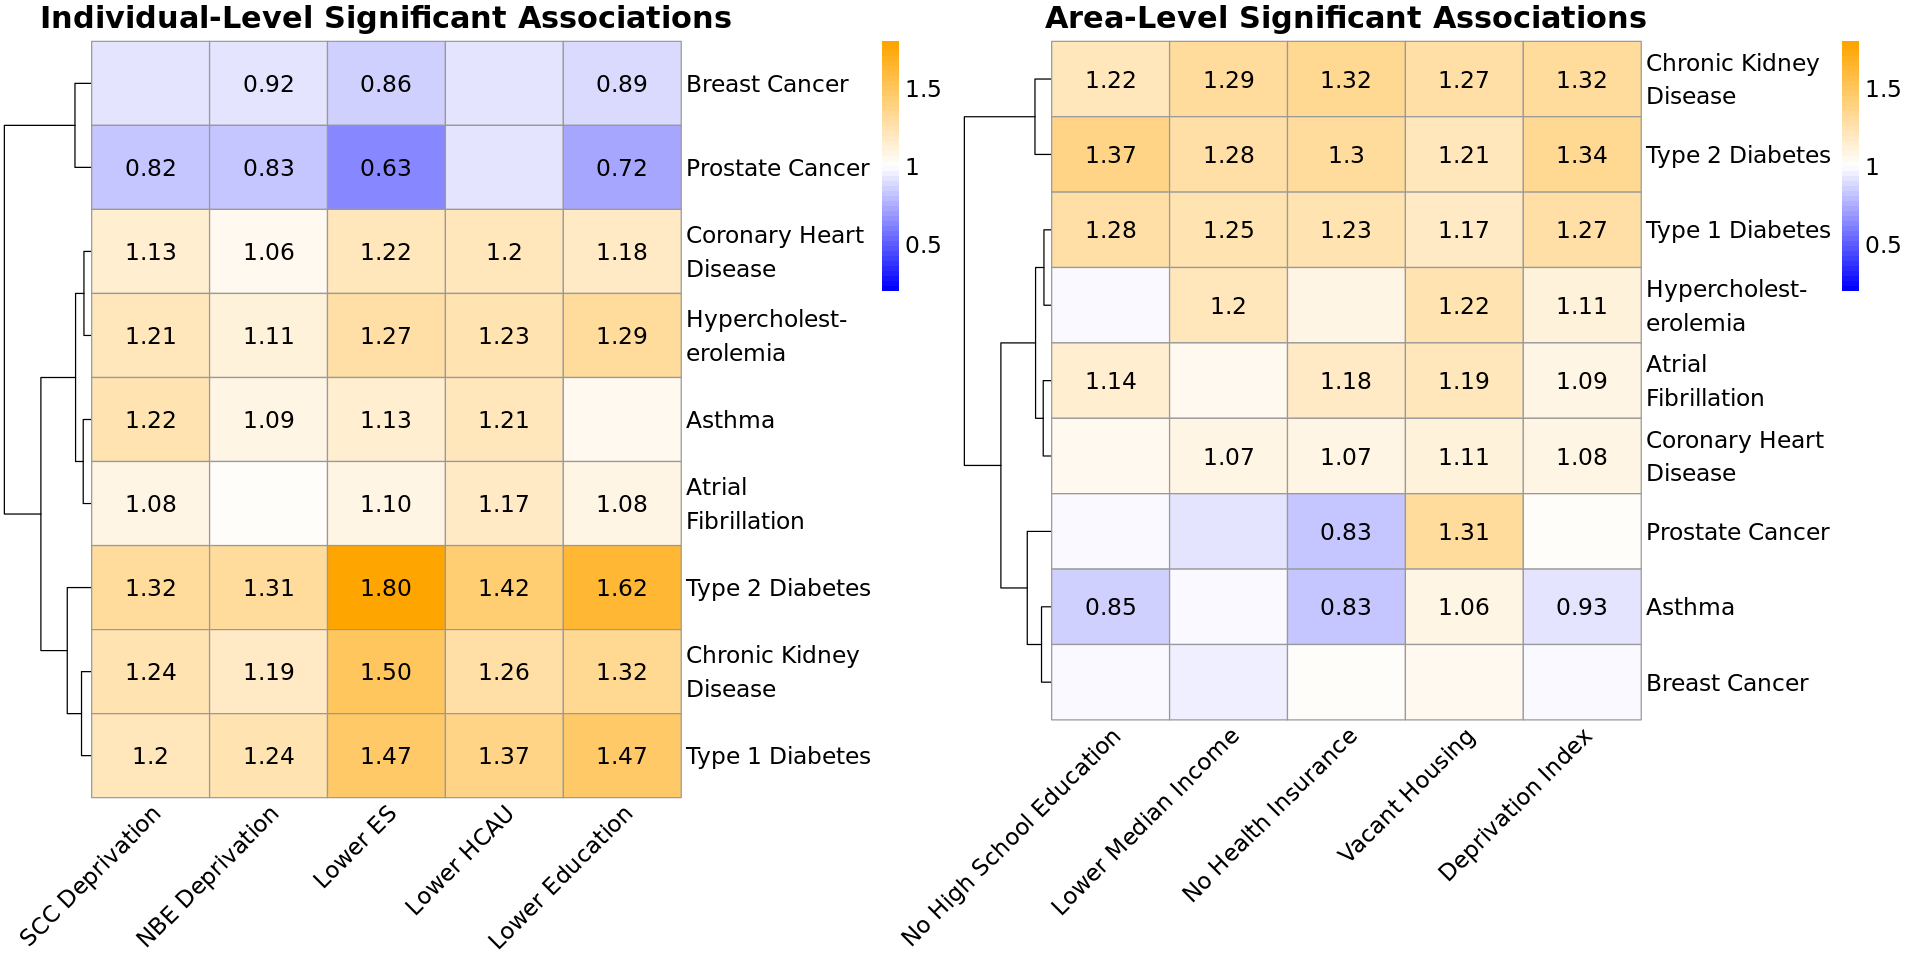

In [15]:
options(repr.plot.width = 16, repr.plot.height = 8)

library(gridExtra)
grid.arrange(ind_map_ordered$gtable, area_map_ordered$gtable, nrow = 1) 


# Stratified Analyses

In [16]:
domains<-c("education", "per_poverty_threshold",
           'high_school_education', 'median_income', 
           'no_health_insurance', 'vacant_housing', 'deprivation_index')

# replace 'test.csv' with the name of the file in your google bucket (don't delete the quotation marks)
name_of_file_in_bucket <- 'SES_cohort.csv'

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)

# Load the file into a dataframe
SES_data <- read_csv(name_of_file_in_bucket)


character(0)

Rows: 125295 Columns: 63
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (6): SexGender, where_born, military, healthcare, disabled, sexual_ori...
dbl  (46): person_id, race_unknown, age_today, LGBTQIA, ehr_length, relative...
lgl   (8): AIAN, Asian, Black, Mid, Multiple, PI, White, His
date  (3): date_of_birth, min_date, max_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [17]:
merged_data<-merge(SES_data, Case_Control_df, on="person_id", how="left")

nrow(merged_data)

[1] 125178

## Load and merge data

## Prepare data

### Z-score norm SDoH variables

In [18]:
merged_data[domains] <- lapply(merged_data[domains], function(x) {
  (x - mean(x, na.rm = TRUE)) / sd(x, na.rm = TRUE)
})



### Make one-hot encoded columns for each level of SexGender

In [19]:
merged_data <- merged_data %>%
  mutate(SexGender = as.factor(SexGender)) %>%
  mutate(dummy = 1) %>%
  pivot_wider(
    names_from = SexGender,
    values_from = dummy,
    values_fill = 0,
    names_prefix = ""
  )


## Stratify data by SIRE

In [20]:
merged_data <- merged_data %>%
  mutate(
    SIRE = case_when(
      Black == 1 & His == 0 ~ "NHB",
      White == 1 & His == 0 ~ "NHW",
      His == 1 ~ "HS",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(SIRE)) 

nrow(merged_data)
table(merged_data$SIRE)

NHB_data <- merged_data[merged_data$SIRE == "NHB", ]
nrow(NHB_data)
NHW_data <- merged_data[merged_data$SIRE == "NHW", ]
nrow(NHW_data)
HS_data <- merged_data[merged_data$SIRE == "HS", ]
nrow(HS_data)

[1] 117426


   HS   NHB   NHW 
14273 20641 82512 

[1] 20641

[1] 82512

[1] 14273

## Generate models

In [21]:
generate_model <- function(disease, domain) {
  # Start with core predictors
  predictors <- c("age", "age2", "record_depth", "visit_frequency")
  
  # Conditional predictors based on disease
  if (disease %in% c("BreastC", "ProstateC")) {
    predictors <- c(predictors, "SGM")  # Include Cis_female and SGM for Breast Cancer
  } else if (disease %in% c("t1d", "CKD")) {
    predictors <- c(predictors, "Cis_male")  
  } else {
    predictors <- c(predictors, "Cis_male", "SGM")  # Include Cis_male and Cis_female for other diseases
  }

  # Add the domain
  predictors <- c(predictors, domain)
  
  # Generate the model syntax
  paste0(disease, " ~ ", paste(predictors, collapse = " + "))
}

# Function to fit model and extract summary
fit_model <- function(model, data, disease, domain) {
    
  if (disease %in% c("t1d", "CKD")) {
    data <- filter(data, SGM == 0)
  }
    
  data_subset <- dplyr::filter(
      data,
  !is.na(.data[[disease]]))
    
   fit <- glm(model, data = data_subset, family = binomial(link = "logit"))

    coef_df <- tidy(fit) %>%
  filter(term %in% domains) %>%        # keep only predictors of interest
  rowwise() %>%                            # operate row-wise for term-specific SD
  mutate(
    SD_predictor = sd(data_subset[[term]], na.rm = TRUE),
    OR = exp(estimate),
    OR_Lower = exp(estimate - 1.96 * std.error),
    OR_Upper = exp(estimate + 1.96 * std.error),
    Disease = disease,
    SDoH_Variable = term
  ) %>%
  ungroup()

  return(coef_df)
    
}


In [22]:
# Generate combinations of diseases and domains
combinations <- expand_grid(disease = diseases, domain = domains)

# Fit SEM models
merged_data<-NHB_data
results_NHB <- combinations %>%
  mutate(
    syntax = map2(disease, domain, generate_model),
    model_results = pmap(list(syntax, list(merged_data), disease, domain), fit_model)
  ) %>%
  select(model_results) %>%
  unnest(model_results)

merged_data<-NHW_data
results_NHW <- combinations %>%
  mutate(
    syntax = map2(disease, domain, generate_model),
    model_results = pmap(list(syntax, list(merged_data), disease, domain), fit_model)
  ) %>%
  select(model_results) %>%
  unnest(model_results)

merged_data<-HS_data
results_HS <- combinations %>%
  mutate(
    syntax = map2(disease, domain, generate_model),
    model_results = pmap(list(syntax, list(merged_data), disease, domain), fit_model)
  ) %>%
  select(model_results) %>%
  unnest(model_results)

In [23]:
label_mapping <- c(
  "vacant_housing" = "Vacant Housing",
  "lower median_income" = "Lower Median Income",
  "no_health_insurance" = "No Health Insurance",
  "no_high_school_education" = "No High School Education",
  "deprivation_index" = "Deprivation Index",
  "per_poverty_threshold" = "Percent Poverty \n Threshold", 
  "education" = "Education"
)

In [24]:
write_excel_csv(results_NHB, 'SDoH_disease_associations_stratified_NHB.csv')

write_excel_csv(results_NHW, 'SDoH_disease_associations_stratified_NHW.csv')

write_excel_csv(results_HS, 'SDoH_disease_associations_stratified_HS.csv')


Warning message in system(paste0("gsutil cp ./SDoH_disease_associatins_stratified_NHB", :
“running command 'gsutil cp ./SDoH_disease_associatins_stratified_NHBgs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/' had status 1”


character(0)
attr(,"status")
[1] 1
attr(,"errmsg")
[1] "Resource temporarily unavailable"

Warning message in system(paste0("gsutil cp ./SDoH_disease_associatins_stratified_NHW", :
“running command 'gsutil cp ./SDoH_disease_associatins_stratified_NHWgs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/' had status 1”


character(0)
attr(,"status")
[1] 1
attr(,"errmsg")
[1] "Resource temporarily unavailable"

Warning message in system(paste0("gsutil cp ./SDoH_disease_associatins_stratified_HS", :
“running command 'gsutil cp ./SDoH_disease_associatins_stratified_HSgs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/' had status 1”


character(0)
attr(,"status")
[1] 1
attr(,"errmsg")
[1] "Resource temporarily unavailable"

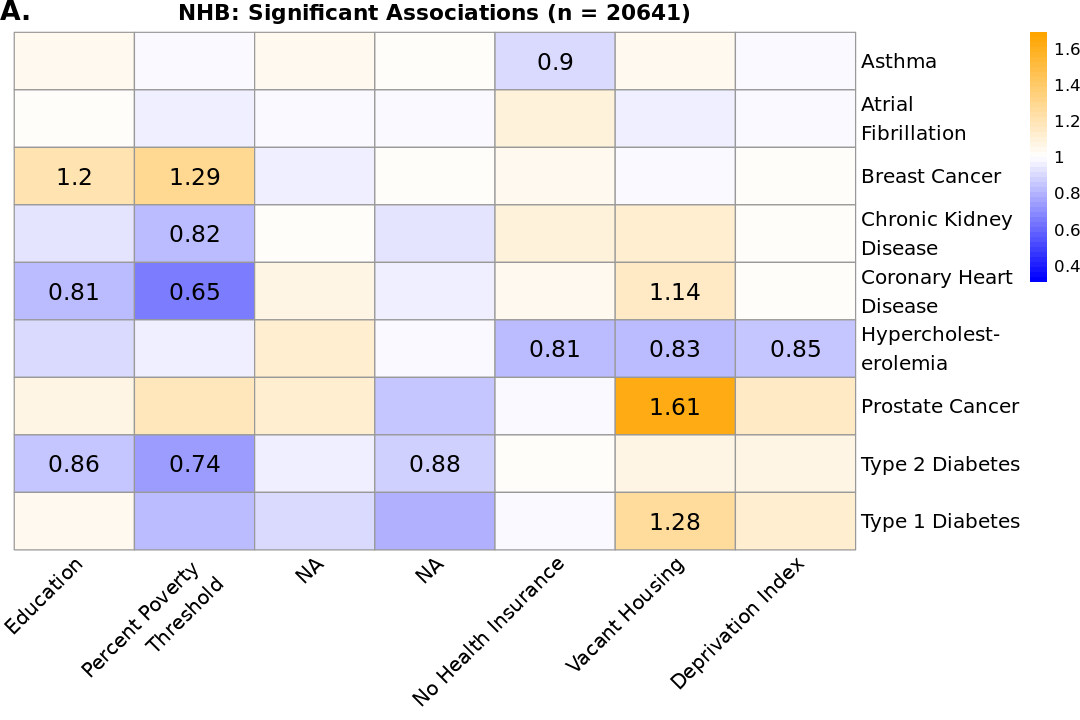

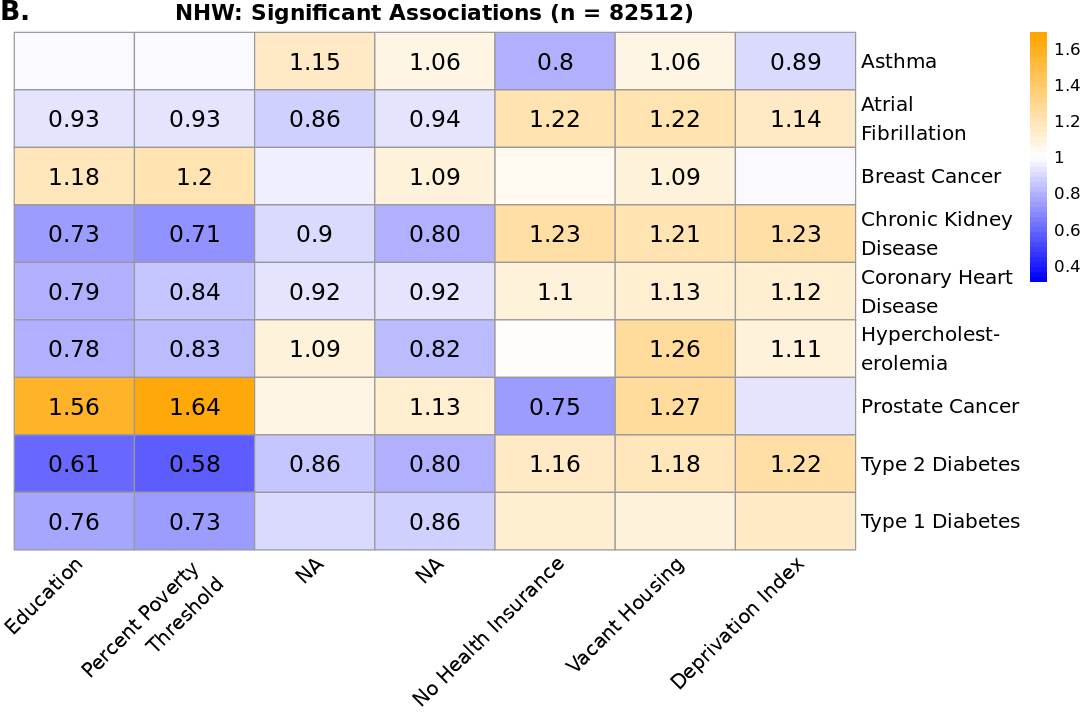

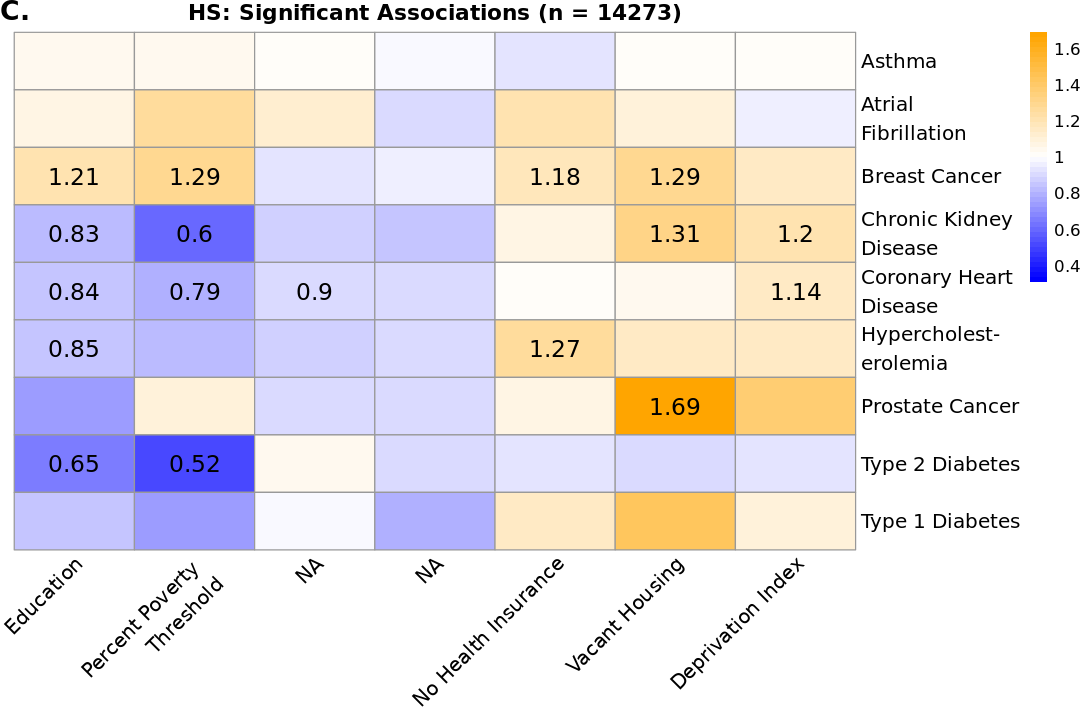

In [25]:
options(repr.plot.width = 9, repr.plot.height = 6)

# List of results and subgroup names
results_list <- list(NHB = results_NHB, NHW = results_NHW, HS = results_HS)

# Store heatmaps
heatmap_outputs <- list()

# Threshold constants
num_traits <- length(unique(results_NHB$Disease))
bonf_alpha <- 0.05 / (num_traits * 13)

#Sample sizes
nrow_NHB <- nrow(NHB_data)
nrow_NHW <- nrow(NHW_data)
nrow_HS <- nrow(HS_data)

# Combine all for consistent color scale
all_combined <- bind_rows(results_NHB, results_NHW, results_HS) %>%
  filter(term %in% domains)

# Compute max for shared color scale
# distance from 1 instead of 0
global_max_dev <- max(abs(all_combined$OR - 1), na.rm = TRUE)
global_breaks <- seq(1 - global_max_dev, 1 + global_max_dev, length.out = 51)
global_palette <- colorRampPalette(c("blue", "white", "orange"))(length(global_breaks) - 1)

make_heatmap <- function(results_subgroup, subgroup_label, nrow_subgroup) {
  all_coefficients_clean <- results_subgroup %>%
    filter(term %in% domains) %>%
    ungroup()
  
  heatmap_data <- all_coefficients_clean %>%
    select(Disease, term, OR) %>%
    pivot_wider(names_from = term, values_from = OR) %>%
    column_to_rownames("Disease")
  
  pvalue_data <- all_coefficients_clean %>%
    select(Disease, term, p.value) %>%
    pivot_wider(names_from = term, values_from = p.value) %>%
    column_to_rownames("Disease")
  
  sig_mask <- pvalue_data < bonf_alpha
  heatmap_labels <- round(heatmap_data, 2)
  heatmap_labels[!sig_mask] <- ""
  
  rownames(heatmap_data) <- disease_name_mapping[rownames(heatmap_data)]
  colnames(heatmap_data) <- label_mapping[colnames(heatmap_data)]
  
  #Getting the order to make the color masks 
  number_colors <- matrix("black", nrow = nrow(heatmap_data), ncol = ncol(heatmap_data))
  number_colors[heatmap_data < -1] <- "white"
    
  
  pheatmap(
    mat = heatmap_data,
    color = global_palette,
    breaks = global_breaks,
    cluster_rows = FALSE,
    cluster_cols = FALSE,
    display_numbers = heatmap_labels,
    number_color = number_colors,
    fontsize_row = 12,
    fontsize_col = 12,
    fontsize_number = 14, 
    angle_col = 45,
    main = paste0(subgroup_label, ": Significant Associations (n = ", nrow_subgroup, ")"),
    width = 3,
    height = 1,
      silent = TRUE
  )
}

# Named vector of sample sizes
sample_sizes <- c(NHB = nrow_NHB, NHW = nrow_NHW, HS = nrow_HS)

# Define subplot labels
subplot_labels <- c("A.", "B.", "C.")
names(subplot_labels) <- names(results_list)


# Generate heatmaps
for (grp in names(results_list)) {
  heatmap_outputs[[grp]] <- make_heatmap(results_list[[grp]], grp, sample_sizes[[grp]])
  
  # Move row labels to the right by adjusting the second column width (where they live)
  heatmap_outputs[[grp]]$gtable$widths[[2]] <- unit(.25, "cm")  # Increase this to move further right

    # Draw heatmap
  grid.newpage()
  grid.draw(heatmap_outputs[[grp]]$gtable)
  
  # Add subplot label (top-left corner)
  grid.text(
    label = subplot_labels[[grp]],
    x = unit(0, "npc"),
    y = unit(1, "npc"),
    just = c("left", "top"),
    gp = gpar(fontsize = 16, fontface = "bold")
      )
    }




## Test of Heterogenity

In [26]:
#install.packages("metafor")
library(metafor)

#Combine into long format
results_long <- bind_rows(
  results_NHB  %>% mutate(Group = "NHB"),
  results_NHW  %>% mutate(Group = "NHW"),
  results_HS   %>% mutate(Group = "HS")
)

# Compute heterogeneity
heterogeneity_results <- results_long %>%
  group_by(Disease, term) %>%
  summarize(
    qtest = list(
      rma(
        yi = cur_data()$estimate, 
        sei = cur_data()$std.error, 
        method = "FE"
      )
    ),
    .groups = "drop"
  )

heterogeneity_summary <- heterogeneity_results %>%
  mutate(
    Q = sapply(qtest, function(x) x$QE),          # Cochran's Q
    Q_p = sapply(qtest, function(x) x$QEp),       # p-value for heterogeneity
    I2 = sapply(qtest, function(x) x$I2)         # I-squared, % of heterogeneity
  ) %>%
  select(Disease, term, Q, Q_p, I2)

# Pivot subgroup results wide
results_wide <- results_long %>%
  select(Disease, term, Group, estimate, std.error, p.value) %>%
  pivot_wider(
    names_from = Group,
    values_from = c(estimate, std.error, p.value),
    names_sep = "."
  )

# Join heterogeneity stats
final_results <- results_wide %>%
  left_join(heterogeneity_summary, by = c("Disease", "term"))


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loading required package: metadat

Loading required package: numDeriv


Loading the 'metafor' package (version 4.8-0). For an
introduction to the package please type: help(metafor)




In [27]:
bonf_p <- .05/nrow(final_results)
bonf_p
nrow(final_results[final_results$Q_p<bonf_p,])

[1] 0.0007936508

[1] 29

In [28]:
final_results[order(final_results$Q_p), ]

Disease,term,estimate.NHB,estimate.NHW,estimate.HS,std.error.NHB,std.error.NHW,std.error.HS,p.value.NHB,p.value.NHW,p.value.HS,Q,Q_p,I2
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
t2d,education,-0.15349033,-0.490561038,-0.42698861,0.02393190,0.01329918,0.02653764,1.420967e-10,7.588678e-298,3.001936e-58,151.87230,1.050385e-33,98.68310
HyperC,vacant_housing,-0.18168321,0.228447663,0.14425763,0.03417797,0.02122667,0.06425611,1.061901e-07,5.186260e-27,2.476547e-02,104.11644,2.462648e-23,98.07907
t2d,deprivation_index,0.06106809,0.202001559,-0.06069187,0.02302514,0.01392111,0.02639681,7.996077e-03,1.040413e-47,2.149287e-02,87.77833,8.693149e-20,97.72153
t2d,no_health_insurance,0.01422013,0.152085628,-0.08167292,0.02434189,0.01354862,0.02412997,5.590968e-01,3.067678e-29,7.125395e-04,80.49983,3.308896e-18,97.51552
ProstateC,education,0.05481290,0.445248120,-0.29009829,0.07369988,0.03007867,0.09672771,4.570391e-01,1.405429e-49,2.707580e-03,69.64248,7.539257e-16,97.12819
HyperC,no_health_insurance,-0.20712896,0.003562635,0.23545252,0.03688298,0.02040988,0.03948328,1.956090e-08,8.614297e-01,2.471218e-09,67.11544,2.667273e-15,97.02006
t2d,high_school_education,-0.04408177,-0.149995889,0.03936973,0.02283961,0.01357600,0.02449236,5.359964e-02,2.226519e-28,1.079603e-01,51.41890,6.831692e-12,96.11038
t2d,vacant_housing,0.06755869,0.164394109,-0.09677693,0.02276142,0.01203570,0.03843933,2.996251e-03,1.787271e-42,1.181393e-02,50.35672,1.161922e-11,96.02834
t2d,per_poverty_threshold,-0.29507569,-0.537704915,-0.65437013,0.03688621,0.01335240,0.04268473,1.248023e-15,0.000000e+00,4.796872e-53,48.84224,2.477665e-11,95.90518


In [29]:
write_excel_csv(final_results, 'SDoH_disease_associations_stratified_heterogeneity.csv')

Warning message in system(paste0("gsutil cp ./SDoH_disease_associatins_stratified_heterogeneity", :
“running command 'gsutil cp ./SDoH_disease_associatins_stratified_heterogeneitygs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/' had status 1”


character(0)
attr(,"status")
[1] 1
attr(,"errmsg")
[1] "Resource temporarily unavailable"

# Plot Distributions

In [30]:
NHB_sdoh <- NHB_data |> select(c("person_id", domains, "SIRE"))
NHW_sdoh <- NHW_data |> select(c("person_id", domains, "SIRE"))
HS_sdoh <- HS_data |> select(c("person_id", domains, "SIRE"))

all_SDoH <- rbind(NHB_sdoh, NHW_sdoh, HS_sdoh)

label_mapping <- c(
    "person_id" = "person_id",
  "vacant_housing" = "Vacant Housing",
  "poverty" = "Poverty",
  "median_income" = "Median Income",
  "no_health_insurance" = "No Health Insurance",
  "high_school_education" = "High School Education",
  "assisted_income" = "Assisted Income",
  "deprivation_index" = "Deprivation Index",
  "per_poverty_threshold" = "Percent Poverty \n Threshold", 
  "education" = "Education",
    "SIRE" = "SIRE"
)

colnames(all_SDoH) <- label_mapping[colnames(all_SDoH)]


all_SDoH_long <- all_SDoH  %>%
  pivot_longer(
    cols = -c(person_id, SIRE),  # keep fixed
    names_to = c("SDoH"),
    values_to = "value"
  )

Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(domains)

  # Now:
  data %>% select(all_of(domains))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”


Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


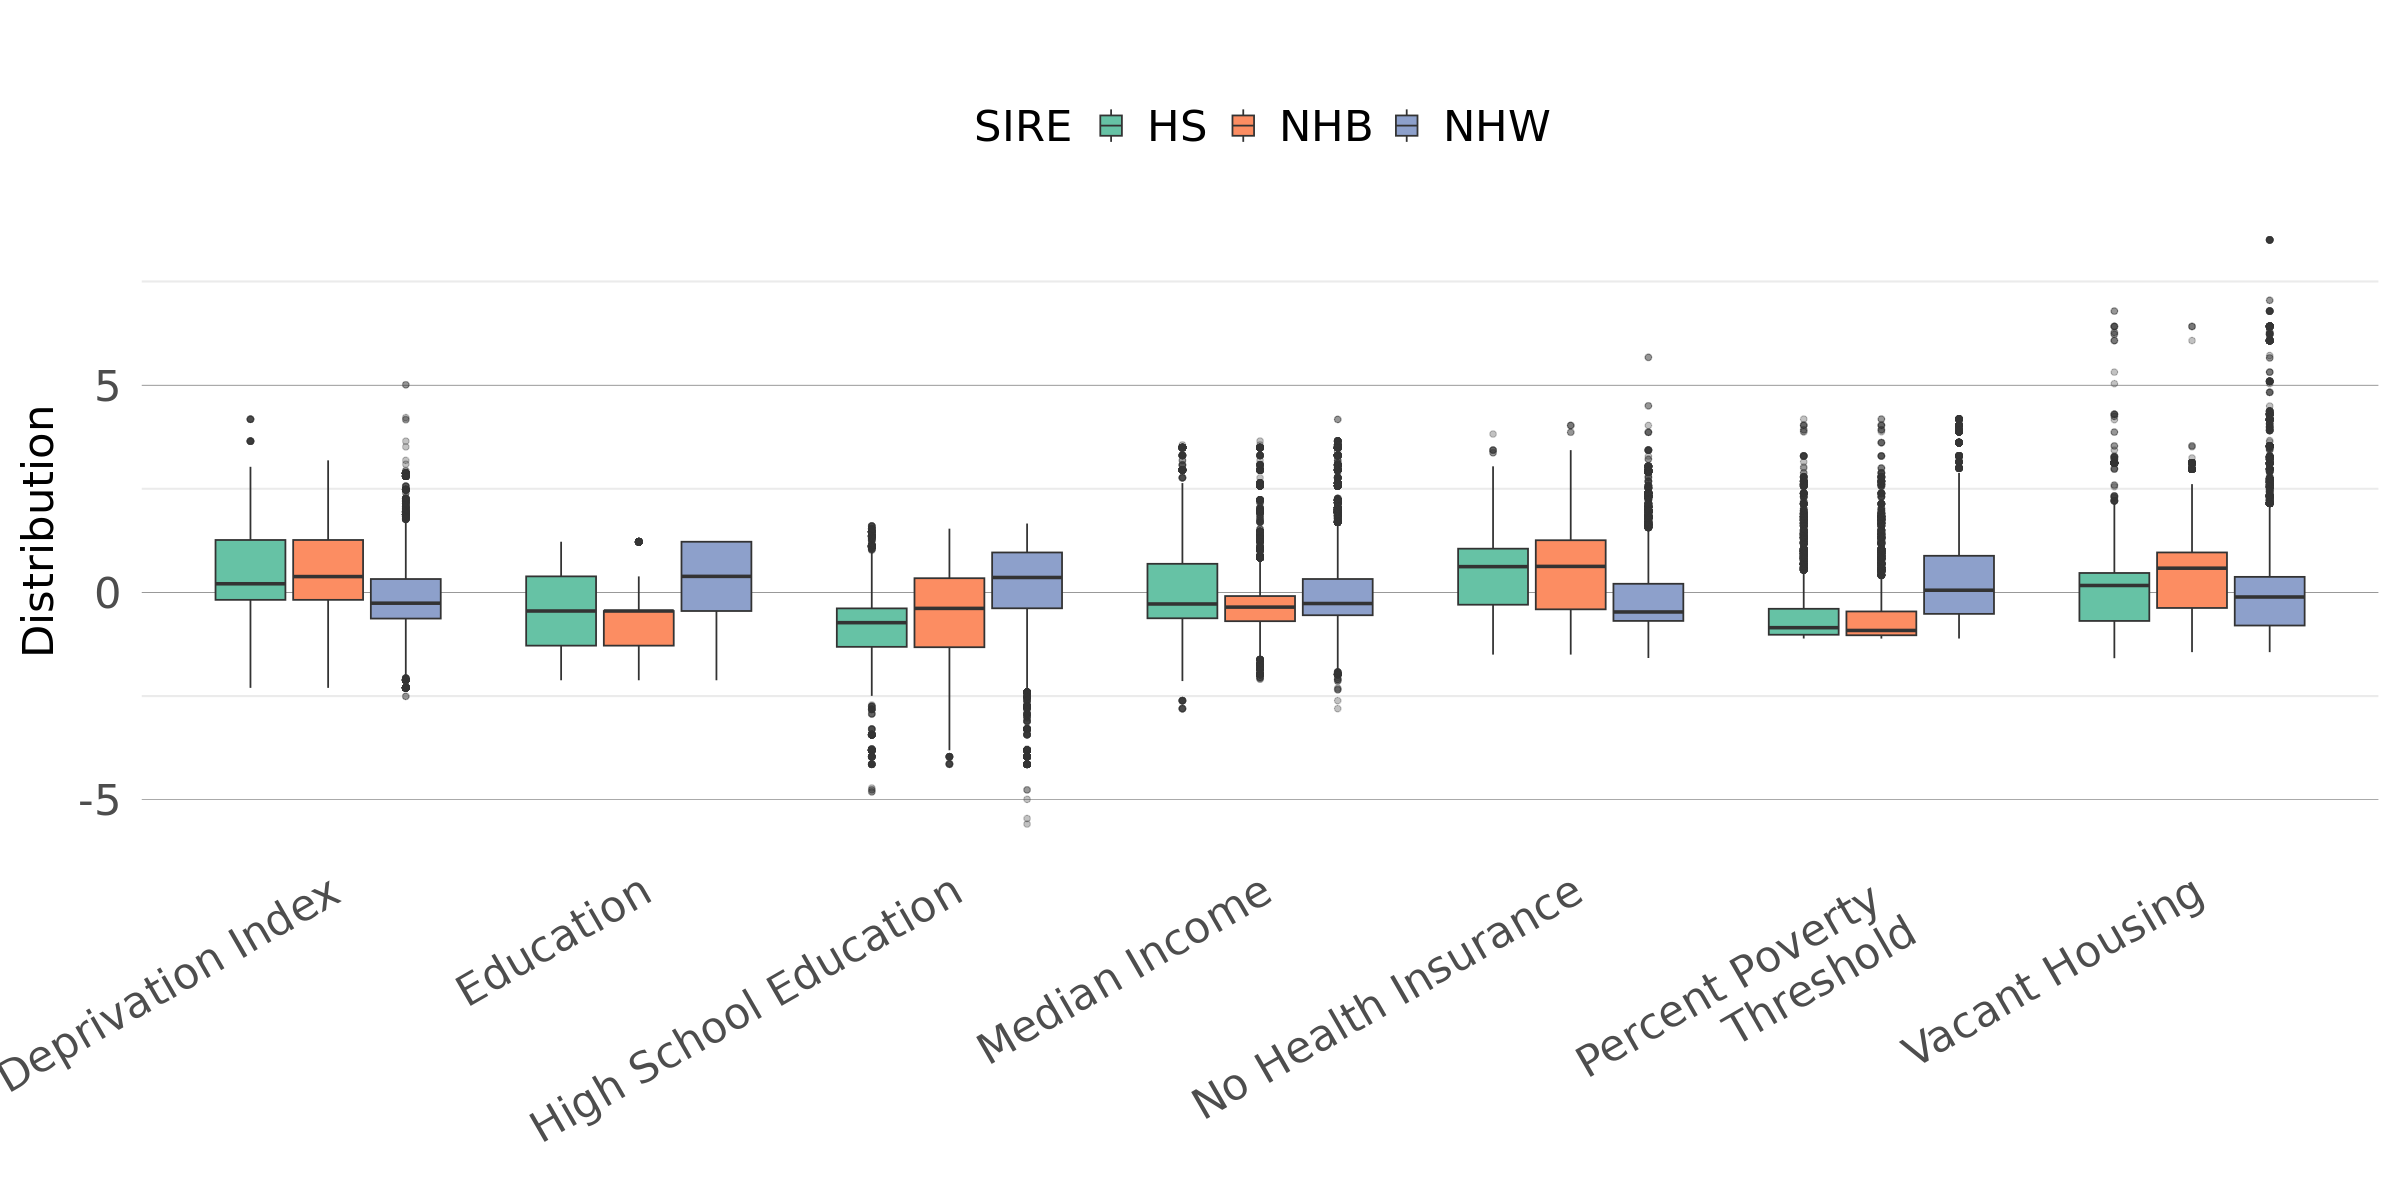

In [31]:
library(RColorBrewer)
options(repr.plot.width = 20, repr.plot.height = 10)

ggplot(all_SDoH_long, aes(x = SDoH, y = value, fill = SIRE)) +
  geom_boxplot(outlier.alpha = 0.3) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom"
  ) +
  labs(
    x = " ",
    y = "Distribution",
    title = " ",
    fill = "SIRE"
  ) +   theme_minimal(base_size = 26) +
  theme(legend.position = "top") + 
  theme(
    axis.text.x = element_text(angle = 30, hjust = 1, size = 26),
    axis.text.y = element_text(size = 26),
    axis.title = element_text(size = 26),
    plot.title = element_text(size = 26, face = "bold", hjust = 0.5),
    legend.title = element_text(size = 26),
    legend.text = element_text(size = 26),
    panel.grid.major.x = element_blank(),
    panel.grid.major.y = element_line(size = 0.1, color = "black")
  ) +
  scale_fill_brewer(palette = "Set2")  # color-blind-friendly palette